# Introducción a K-Means

Este notebook está pensado para **estudiar el algoritmo K-Means paso a paso** usando un dataset de familias con **ingresos, gastos y ahorro**.

## Indicaciones
Intenta responder a estos puntos.
- Comprender qué problema resuelve K-Means.
- Explorar el dataset antes de agrupar.
- Seleccionar variables con criterio.
- Entender por qué hay que escalar los datos.
- Aplicar K-Means con distintos valores de `k`.
- Utilizar el método Elbow (del codo)
- Interpretar los centroides y los clusters.

> Nota: comenta cada resultado antes de pasar a la siguiente.

## 1. Cargar librerías y dataset

En esta primera parte cargamos:
- el dataset de familias,
- las librerías de análisis,
- y una vista inicial de los datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Cambia la ruta si guardas el CSV en otra carpeta
df = pd.read_csv("05_familias_gastos_ingresos_300.csv")
df.head()

,id_hogar,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
0,1,35319.00,10502.35,5293.46,5241.74,4041.16,2105.42,2977.06,5157.80
1,2,53484.00,13454.40,8395.17,6076.10,3031.31,2884.73,4554.92,15087.36
2,3,50007.61,13698.41,8949.33,4634.47,3666.31,3800.52,5091.09,10167.47
3,4,39437.43,11906.00,7375.84,5084.38,3600.76,1091.38,6025.64,4353.43
4,5,12000.00,3187.00,2718.18,1628.21,840.63,467.12,981.27,2177.59


## 2. Primer vistazo al dataset

Antes de usar cualquier algoritmo, hay que entender los datos:
- cuántas filas hay,
- qué variables tenemos,
- si hay valores nulos,
- y qué magnitudes manejamos.

In [6]:
#filas

print(f"Hay {df.shape[0]} filas")

Hay 300 filas


In [ ]:
#variables

#Tenemos las variables de ingresos, gastos y ahorros.
#Ingresos y gastos solamente hay una por cada, pero de gastos tenemos varias categorias, en total 7.
#Pero las variables que yo utilizaria son las de ingreso y gasto de ocio que al final es la variable que mas puede variar, porque cosas como la salud o la vivienda... 
# no puede bajar o cambiarse a gusto de uno.

In [7]:
#cómo son los datos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_hogar            300 non-null    int64  
 1   ingreso_anual       300 non-null    float64
 2   gasto_vivienda      300 non-null    float64
 3   gasto_alimentacion  300 non-null    float64
 4   gasto_transporte    300 non-null    float64
 5   gasto_ocio          300 non-null    float64
 6   gasto_salud         300 non-null    float64
 7   gasto_educacion     300 non-null    float64
 8   ahorro              300 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 21.2 KB


In [ ]:
#hay nulos o no
#Comprobamos que no hay nulos.
df.isnull().sum()

id_hogar              0
ingreso_anual         0
gasto_vivienda        0
gasto_alimentacion    0
gasto_transporte      0
gasto_ocio            0
gasto_salud           0
gasto_educacion       0
ahorro                0
dtype: int64

## 3. Comprender el problema

K-Means es un algoritmo de **aprendizaje no supervisado**.
Eso significa que:
- no hay una columna objetivo,
- no hay etiquetas previas,
- y el objetivo es **descubrir grupos similares** en los datos.

En este caso queremos detectar perfiles de familias, por ejemplo:
- Familia tipo 1: .....
- Familia tipo 2: .....
- Familia tipo 3: .....

## 4. Selección inicial de variables

No siempre interesa usar todas las columnas desde el principio.
Para empezar, vamos a observar una relación muy intuitiva:

- `ingreso_anual`
- `gasto_ocio`

Esto permite una primera visualización sencilla del problema.

In [9]:
X_simple = df[["ingreso_anual", "gasto_ocio"]]
X_simple.head()

,ingreso_anual,gasto_ocio
0,35319.00,4041.16
1,53484.00,3031.31
2,50007.61,3666.31
3,39437.43,3600.76
4,12000.00,840.63


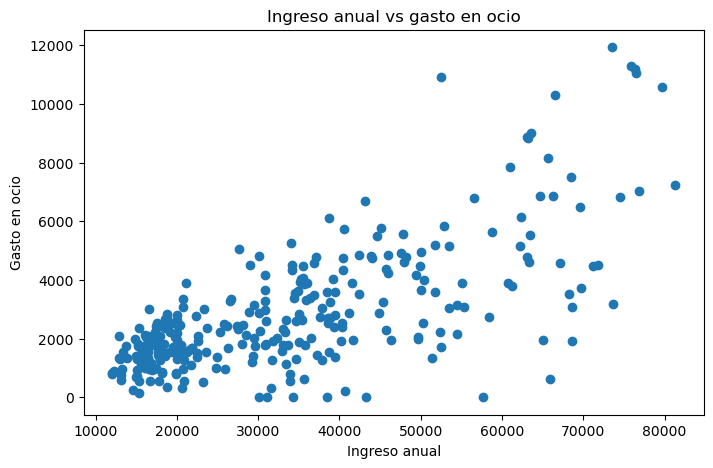

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(df["ingreso_anual"], df["gasto_ocio"])
plt.xlabel("Ingreso anual")
plt.ylabel("Gasto en ocio")
plt.title("Ingreso anual vs gasto en ocio")
plt.show()

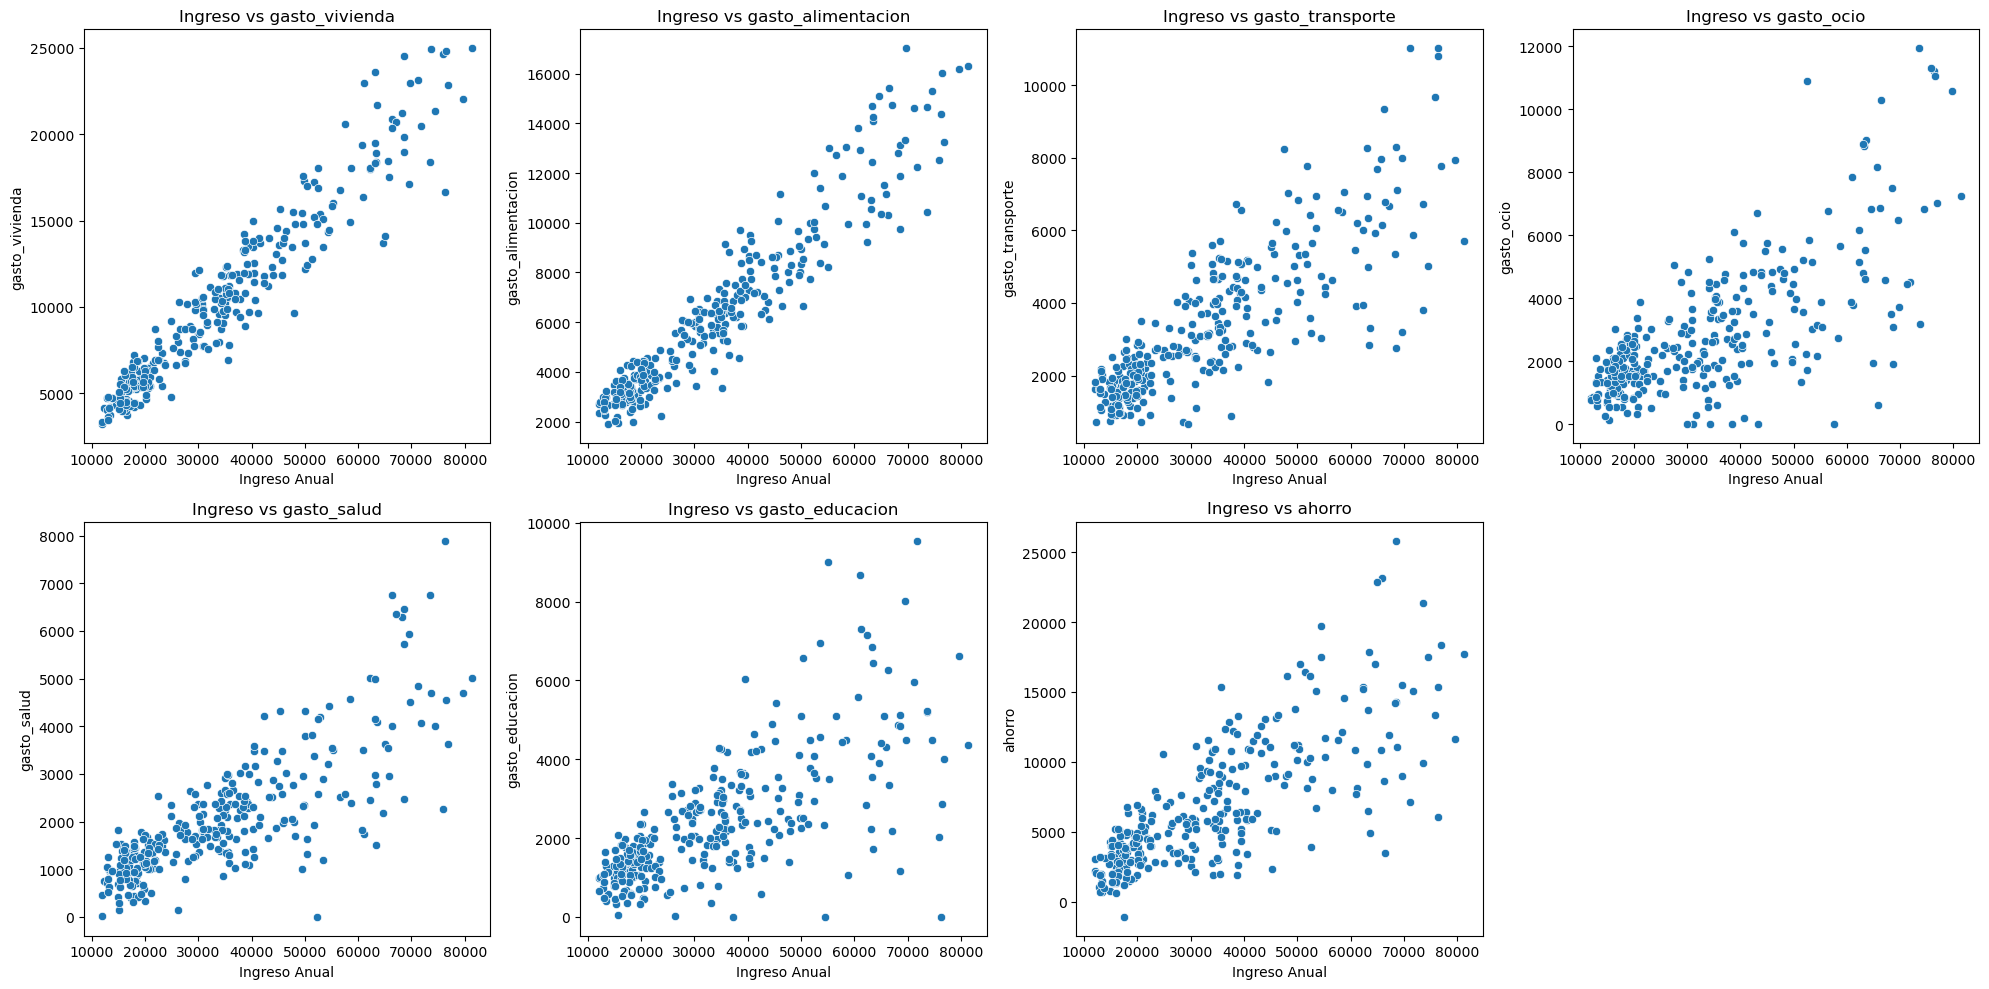

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de las columnas de gastos (todas menos ingreso_anual)
gastos = [
    "gasto_vivienda", "gasto_alimentacion", "gasto_transporte", 
    "gasto_ocio", "gasto_salud", "gasto_educacion", "ahorro"
]

# Configuramos la cuadrícula (ejemplo: 2 filas x 4 columnas)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten() # Aplanamos para iterar fácilmente

for i, columna in enumerate(gastos):
    sns.scatterplot(data=df, x="ingreso_anual", y=columna, ax=axes[i])
    axes[i].set_title(f"Ingreso vs {columna}")
    axes[i].set_xlabel("Ingreso Anual")
    axes[i].set_ylabel(columna)

# Eliminamos el último gráfico si sobra espacio (el 8º hueco)
if len(gastos) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Cuestiones
1. ¿Se distinguen grupos visualmente?
- Yo distinguiria 4 grupos; 
Se podrían distinguir entre; 
(1) familias vulnerables, las cuales gastan poco porque su presupuesto es limitado.
(2) familias estandar, las cuales tienen gastos equitativos a su presupuesto.
(3) familias con alto nivel de consumo; las cuales tienen ingresos altos y a la par gastan mucho.
(4) familias ahorradoras; las cuales tienen un alto presupuesto pero no tienen un gran gasto en el ocio.
2. ¿Parece haber familias con ingresos parecidos pero distinto gasto en ocio?
- Si, algunos tienen ingresos muy altos y en ocio gastan muy poco, como el primer grupo de ingresos anuales menor.
3. ¿Crees que con solo dos variables será suficiente?
- No, yo creo que para sacar algo coherente y un racionamiento interesante se deberían de utilizar todas las que hay en el dataset, incluso estaría mejor tener más variables; porque con las que tenemos una decisión o unos consejos claros de ahorros no se pueden dar.

## 5. Primer K-Means con `k = 3`

Empieza con una prueba sencilla.
Aquí el algoritmo:
1. Fija un número de grupos `k`,
2. Busca centroides,
3. Asigna cada familia al centroide más cercano.

In [19]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3.fit(X_simple)

labels_3 = kmeans_3.labels_
centroides_3 = kmeans_3.cluster_centers_

print("Centroides:")
print(centroides_3)

Centroides:
[[18685.46454545  1672.61075758]
 [63753.68980769  5573.08115385]
 [37749.7662069   2994.94077586]]


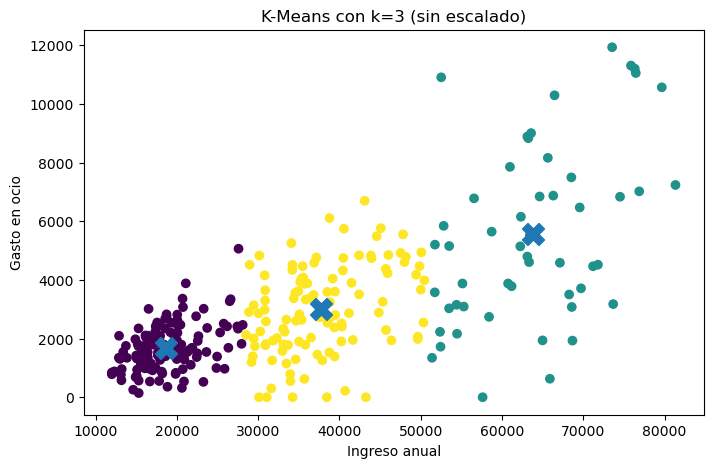

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(X_simple["ingreso_anual"], X_simple["gasto_ocio"], c=labels_3)
plt.scatter(centroides_3[:,0], centroides_3[:,1], marker="X", s=250)
plt.xlabel("Ingreso anual")
plt.ylabel("Gasto en ocio")
plt.title("K-Means con k=3 (sin escalado)")
plt.show()

## 6. Interpretar los centroides

Los centroides representan el “centro” de cada grupo.

Conviene pasarlos a tabla para interpretarlos mejor.

In [16]:
pd.DataFrame(centroides_3, columns=X_simple.columns)

,ingreso_anual,gasto_ocio
0,18685.464545,1672.610758
1,63753.689808,5573.081154
2,37749.766207,2994.940776


### Cuestione
1. ¿Qué clúster tiene el mayor ingreso medio?
- El cluster que tiene mayor ingreso medio es el 1. Es porque es el grupo donde estan las familias en el mayor rango de ingresos anuales y hay bastantes en ese rango.
2. ¿Cuál tiene menor gasto en ocio?
- El cluster que tiene menor gasto en ocio es el 0, y tiene todo el sentido del mundo porque pertenece al grupo que asigné antes; que son las familias vulnerables, las cuales no tiene mucho gasto de ocio porque no tiene un nivel alto de ingresos altos.
3. ¿Cómo describirías cada grupo con palabras?
- El primer grupo;
Grupo de familias que tienen poco ingreso anual y a la par, poco gasto en ocio.
- El segundo grupo;
Grupo de familias que tienen un gran ingreso anual y a la par, un gran gasto en ocio.
- El tercer grupo;
Grupo de familias "intermedias", que tienen un sueldo algo mayor, y gastan entorno a ello.

## 7. Probar distintos valores de `k`

K-Means necesita que indiques el número de grupos.
Repite el proceso con distintos valores para ver cómo cambia el resultado.

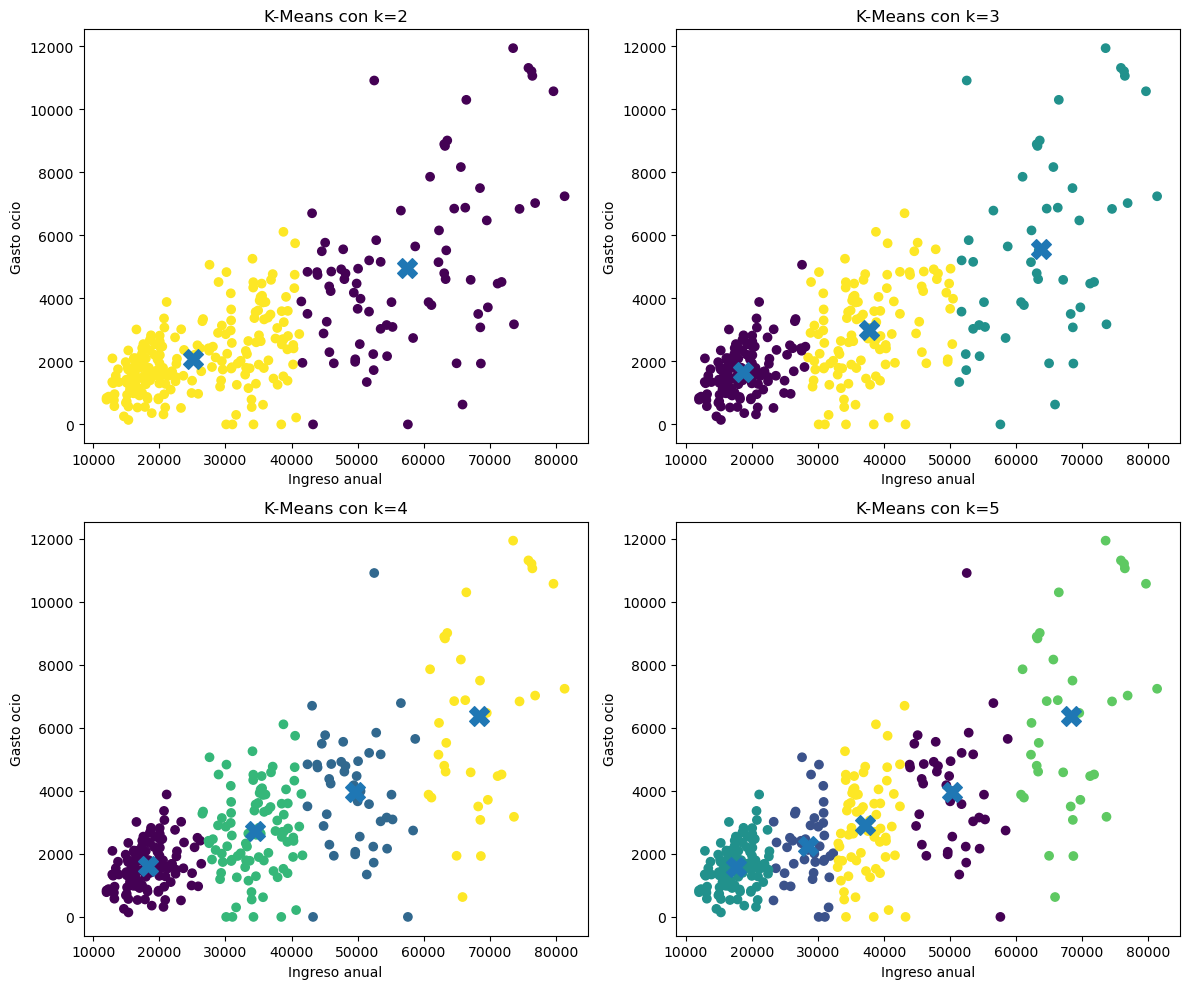

In [21]:
valores_k = [2, 3, 4, 5]

plt.figure(figsize=(12, 10))

for i, k in enumerate(valores_k, start=1):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_simple)
    centros = modelo.cluster_centers_

    plt.subplot(2, 2, i)
    plt.scatter(X_simple["ingreso_anual"], X_simple["gasto_ocio"], c=etiquetas)
    plt.scatter(centros[:,0], centros[:,1], marker="X", s=200)
    plt.title(f"K-Means con k={k}")
    plt.xlabel("Ingreso anual")
    plt.ylabel("Gasto ocio")

plt.tight_layout()
plt.show()

## 8. Método Elbow (Método del codo)

Una forma clásica de elegir `k` es calcular la **inercia** para distintos valores.
La inercia mide, en términos simples, lo compactos que quedan los grupos.

Buscamos el punto en que la mejora deja de ser tan grande.

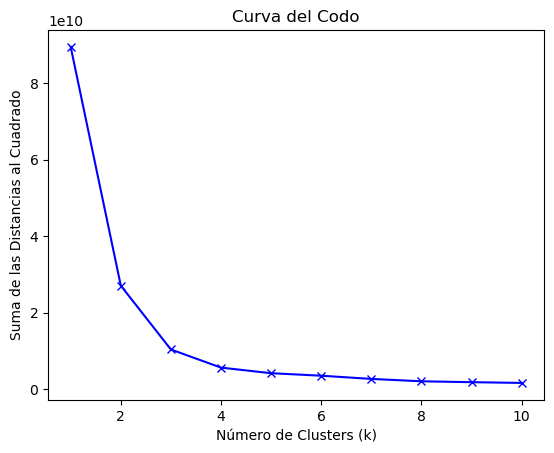

In [25]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def elbow_method(data, max_clusters=10):
    """
    Aplica el método del codo para seleccionar el número óptimo de clusters en k-means.

    Parámetros:
    ----------
    data : matriz o matriz dispersa, forma (n_samples, n_features)
        Los datos de entrada.

    max_clusters : int, opcional (por defecto=10)
        El número máximo de clusters a considerar.
    """

    sum_of_squared_distances = []

    for k in range(1, max_clusters+1):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)
        sum_of_squared_distances.append(kmeans.inertia_)

    # Graficar la curva del codo
    plt.plot(range(1, max_clusters+1), sum_of_squared_distances, 'bx-')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Suma de las Distancias al Cuadrado')
    plt.title('Curva del Codo')
    plt.show()

datos_seleccionados = df[["ingreso_anual", "gasto_ocio"]]

elbow_method(datos_seleccionados)

### Cuestiones
1. ¿En qué valor de `k` parece estar el “codo”?
- El valor k esta en el 3.
2. ¿Ese valor coincide con lo que observabas en la gráfica?
- Si, ya que probando con 4, no lo veia del todo, y menos si aumentamos algun cluster mas.
3. ¿Crees que hay una única respuesta correcta?
- No, yo creo que al final puede variar la respuesta dependiendo de como lo interpretes o lo quieras interpretar, yo diría que 3/4 diferenciandolas como las he hecho anteriormente.

## 9. ¿Por qué es importante escalar?

K-Means trabaja con distancias.
Si una variable tiene valores mucho más grandes que otra, dominará el resultado.

Lo puedes comprobar ampliando las variables:
- ingresos,
- varios tipos de gasto,
- ahorro.

In [26]:
columnas_modelo = [
    "ingreso_anual",
    "gasto_vivienda",
    "gasto_alimentacion",
    "gasto_transporte",
    "gasto_ocio",
    "gasto_salud",
    "gasto_educacion",
    "ahorro"
]

X = df[columnas_modelo]
X.head()

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
0,35319.00,10502.35,5293.46,5241.74,4041.16,2105.42,2977.06,5157.80
1,53484.00,13454.40,8395.17,6076.10,3031.31,2884.73,4554.92,15087.36
2,50007.61,13698.41,8949.33,4634.47,3666.31,3800.52,5091.09,10167.47
3,39437.43,11906.00,7375.84,5084.38,3600.76,1091.38,6025.64,4353.43
4,12000.00,3187.00,2718.18,1628.21,840.63,467.12,981.27,2177.59


In [ ]:
X.describe().T

Observa que:
- `ingreso_anual` tiene una magnitud muy superior,
- y algunas variables de gasto tienen escalas bastante distintas.

Por eso vamos a comparar el clustering:
1. **sin escalado**
2. **con escalado**

In [27]:
modelo_sin_escalar = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_sin_escalar = modelo_sin_escalar.fit_predict(X)

df["cluster_sin_escalar"] = labels_sin_escalar
df.groupby("cluster_sin_escalar")[columnas_modelo].mean().round(2)

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
cluster_sin_escalar,,,,,,,,
0,36687.48,11021.95,6686.03,3819.94,2944.20,2163.72,2574.52,7477.13
1,61909.99,18339.81,11673.12,5979.66,5293.97,3645.94,4334.50,12642.99
2,18541.72,5578.23,3401.37,1853.22,1665.37,1122.42,1320.78,3600.33


In [28]:
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

modelo_escalado = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_escalado = modelo_escalado.fit_predict(X_escalado)

df["cluster_escalado"] = labels_escalado
df.groupby("cluster_escalado")[columnas_modelo].mean().round(2)

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
cluster_escalado,,,,,,,,
0,63685.94,18924.72,12117.77,6284.49,5740.63,3922.85,4616.86,12078.62
1,18549.74,5593.97,3403.43,1847.88,1640.81,1117.76,1307.80,3638.09
2,37825.18,11307.53,6870.39,3858.47,2957.31,2162.25,2600.79,8068.45


## 10. Comparación de resultados

Ahora compara las medias de cada cluster:
- ¿son más coherentes tras escalar?
- Si, ya que fijandonos en los puntos de la zona de las familias vulnerables, se nota como la mayoria estan muy pegados unos con otros lo que significa y da valor a que se ve mejor reflajado con los clusteres escalados (51).
- ¿parece que el modelo recoge mejor el comportamiento global de las familias?
- Si, parece que lo recoge bastante mejor, ya que como decia antes, donde se ve que hay menos datos y estan todos juntos es el la parte de familias vulnerables, luego, los otros dos grupos ocupan mas parte de grafica y tienen mas datos.

In [29]:
print("Distribución de familias por cluster (sin escalar):")
print(df["cluster_sin_escalar"].value_counts().sort_index())

print("\nDistribución de familias por cluster (escalado):")
print(df["cluster_escalado"].value_counts().sort_index())

Distribución de familias por cluster (sin escalar):
cluster_sin_escalar
0    110
1     60
2    130
Name: count, dtype: int64

Distribución de familias por cluster (escalado):
cluster_escalado
0     51
1    130
2    119
Name: count, dtype: int64


## 11. Centroides del modelo escalado

Como los centroides escalados son difíciles de interpretar directamente,
vamos a devolverlos a la escala original.

In [30]:
centroides_escalados = modelo_escalado.cluster_centers_
centroides_originales = scaler.inverse_transform(centroides_escalados)

pd.DataFrame(centroides_originales, columns=columnas_modelo).round(2)

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
0,63685.94,18924.72,12117.77,6284.49,5740.63,3922.85,4616.86,12078.62
1,18549.74,5593.97,3403.43,1847.88,1640.81,1117.76,1307.80,3638.09
2,37825.18,11307.53,6870.39,3858.47,2957.31,2162.25,2600.79,8068.45


### Cuestiones
1. ¿Qué clúster representa familias con más ingresos?
- El cluster que representa familias con mas ingresos es el 0, que define el grupo de la derecha del todo, donde aparecen las familias con mas ingresos.
2. ¿Qué clúster parece más vulnerable?
- El cluster mas vulnerable es el 1; ya que se ve como es el que menor ingresos tienen, junto con todos los gastos, que también son los mas pequeños.
3. ¿Cuál parece más ahorrador?
- El mas ahorrador fijandonos solamente en la columna de "ahorro" seria el 0, el que mayores ingresos tiene. Pero tambien entiendo que no es proporcional; ya que tiene bastantes mas ingresos anuales que el cluster 2 que es el "intermedio". Entonces se entiende casi que; si tienes mas ingresos, lo mas probable es que tengas mas dinero, pero no significa que ahorres más que el cluster 2 proporcionalmente. (sin calcular porcentajes, es lo que veo a simple vista).
4. ¿Ves relación entre ingresos altos y mayor gasto en algunas categorías?
- Donde si se ve claro es que en el cluster 2, va bastante "de la mano" que el ingreso sea algo con el gasto de vivienda, que es bastante alto.

## 12. Interpretación final de clusters

Redacta una interpretación breve de cada cluster.

Modelo de ejemplo:

- **Cluster A**: familias de alto nivel economico, las cuales a la par, también gastan bastante.
- **Cluster B**: familias más vulnerables, las cuales tienen unos ingresos bajos y gastos lo mismo.
- **Cluster C**: familias mas estandar, "intermedias", de las cuales estan bastante a la par; los gastos y los ingresos.

Lo importante no es solo ejecutar K-Means, sino **dar sentido a los grupos**.

## 13. Actividad de ampliación

Prueba alguna de estas variantes:
- usar solo ingresos y ahorro,
- usar ingresos, vivienda, alimentación y ocio,
- probar `k = 4`,
- comparar resultados con y sin la variable `ahorro`,
- detectar si algunos hogares quedan en clusters poco claros.

Esto te ayudará a entender que en Aprendizaje No Supervisado las decisiones sobre variables y preparación de datos cambian el resultado.
> Resumiendo: K-Means no “descubre la verdad”; propone agrupaciones a partir de cómo le damos los datos.

Ingresos y ahorro.

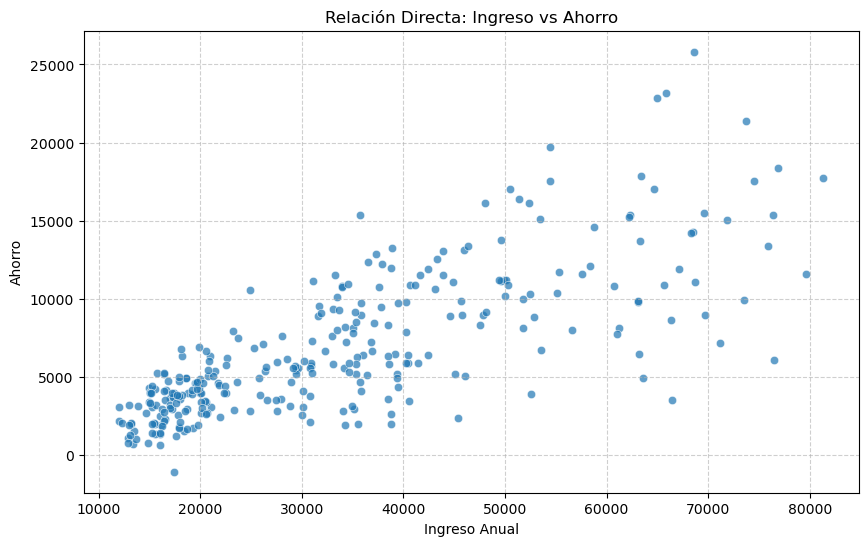

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico para validar tu teoría de Ingreso vs Ahorro
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ingreso_anual', y='ahorro', alpha=0.7)

plt.title('Relación Directa: Ingreso vs Ahorro')
plt.xlabel('Ingreso Anual')
plt.ylabel('Ahorro')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

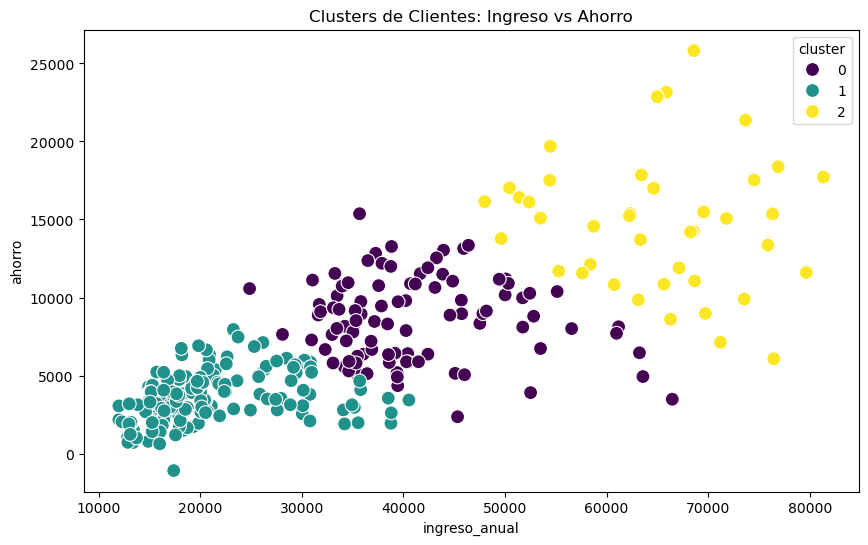

In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Seleccionamos las variables
# Opción 1: Solo ingreso y ahorro
X = df[['ingreso_anual', 'ahorro']]

# 1. Escalado (Fundamental para que el ingreso no "aplaste" al ahorro)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Creamos el modelo (suponiendo 3 grupos por lo que vimos en el codo)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 3. Gráfico final con los clusters pintados
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ingreso_anual', y='ahorro', hue='cluster', palette='viridis', s=100)

plt.title('Clusters de Clientes: Ingreso vs Ahorro')
plt.show()